In [1]:
import pandas as pd
import numpy as np 
from pathlib import Path
data_path=Path(r'C:\Users\vinee\ML_Project\data\raw\electricity_consumption_raw.csv')
df=pd.read_csv(data_path)

In [2]:
meta_col=['CONS_NO','FLAG']
date_col=[col for col in df.columns if col not in meta_col ]
print('dataset shape',df.shape)
print('consumption columns',len(date_col))

dataset shape (42372, 1036)
consumption columns 1034


### Missing values per consumer

In [3]:
con_data=df[date_col]
miss_p_csr= con_data.isnull().sum(axis=1)
miss_summ=pd.DataFrame({
    'CONS_NO':df['CONS_NO'],
    "FLAG":df['FLAG'],
    'Missing_days':miss_p_csr
})
miss_summ['missing_pct']=(miss_summ['Missing_days']/len(date_col)*100)
miss_summ.head(2)

,CONS_NO,FLAG,Missing_days,missing_pct
0,0387DD8A07E07FDA6271170F86AD9151,1,4,0.386847
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,188,18.181818


#### FLAG wise missing values

In [4]:
miss_by_flag=(miss_summ.groupby('FLAG')['missing_pct'].agg(['count','mean','median','min','max']))
miss_by_flag

,count,mean,median,min,max
FLAG,,,,,
0,38757,25.096246,9.284333,0.096712,100.0
1,3615,31.468735,21.373308,0.096712,100.0


#### Missing distribution graph

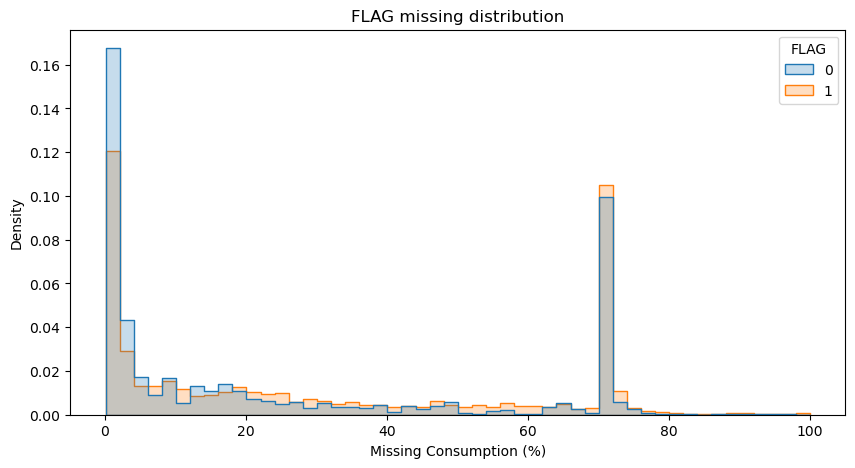

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(data=miss_summ,x='missing_pct',hue='FLAG',bins=50,element='step',stat='density',common_norm=False)
plt.xlabel('Missing Consumption (%)')
plt.ylabel("Density")
plt.title('FLAG missing distribution')
plt.show()

In [6]:
complete_miss=miss_summ[miss_summ['Missing_days']==len(date_col)]
print('100% missing consumption',len(complete_miss))
complete_miss['FLAG'].value_counts()

100% missing consumption 5


FLAG
1    3
0    2
Name: count, dtype: int64

#### High missingness consumers

In [7]:
high_miss=miss_summ[miss_summ['missing_pct']>=50]
print('consumer with 50% miss data',len(high_miss))
print('Flag distributionn')
print(high_miss['FLAG'].value_counts(normalize=True)*100)


consumer with 50% miss data 11187
Flag distributionn
FLAG
0    89.201752
1    10.798248
Name: proportion, dtype: float64


#### Missing values by datess


In [8]:
miss_per_date=con_data.isnull().sum(axis=0)
miss_date_summ=pd.DataFrame({
    "date":pd.to_datetime(date_col,format="%m/%d/%Y"),
    'missing consumers':miss_per_date.values
})
miss_date_summ['missing_pct']=(miss_date_summ['missing consumers']/len(df)*100)
miss_date_summ.sort_values('missing_pct',ascending=False).head(5)

,date,missing consumers,missing_pct
275,2014-10-03,42357,99.964599
77,2014-03-19,21505,50.752856
58,2014-02-28,20985,49.525630
62,2014-03-04,20820,49.136222
61,2014-03-03,20806,49.103181


#### Visualization of missingness

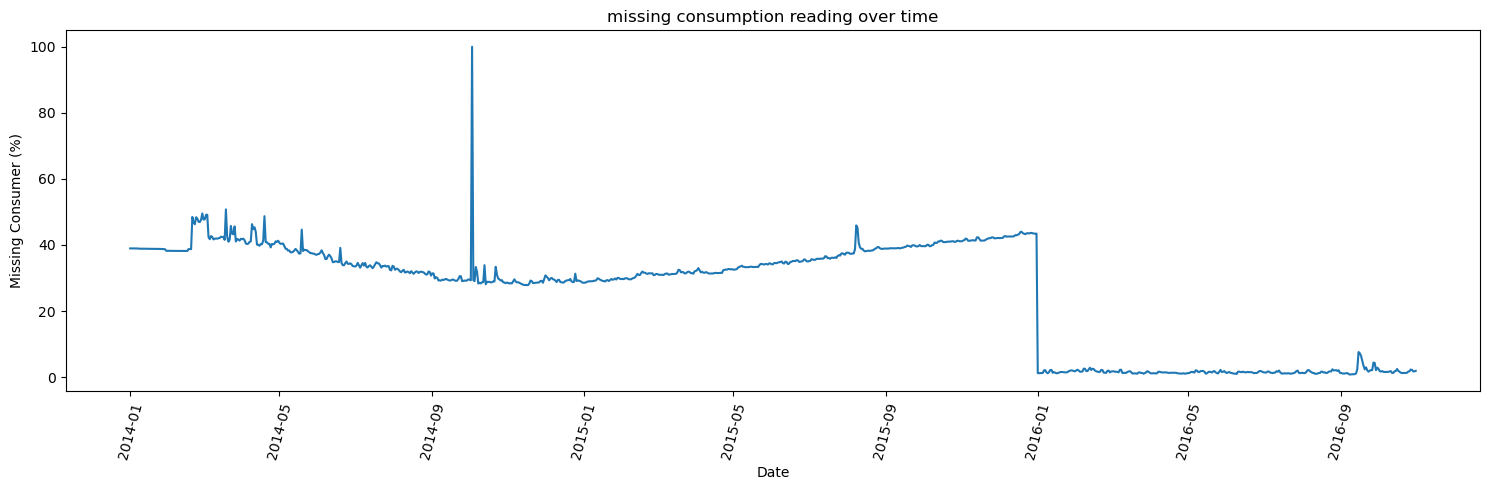

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(15,5))
plt.plot(miss_date_summ['date'],miss_date_summ['missing_pct'])
plt.xlabel('Date')
plt.ylabel('Missing Consumer (%)')
plt.title("missing consumption reading over time")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [10]:
quality_summ={
    'total_consumers':len(df),
    'total_consumption_days':len(date_col),
    'total_missing_cells':int(con_data.isnull().sum().sum()),
    'complete_missing_consumers': int((miss_summ["Missing_days"] == len(date_col)).sum()),
    'high_missing_consumer_50pct': int((miss_summ["missing_pct"] >=50).sum()),
    'Overall_missing_percentage' : ((con_data.isnull().sum().sum()/con_data.size)*100)
}
quality_summ

{'total_consumers': 42372,
 'total_consumption_days': 1034,
 'total_missing_cells': 11233528,
 'complete_missing_consumers': 5,
 'high_missing_consumer_50pct': 11187,
 'Overall_missing_percentage': np.float64(25.639920234905684)}

### Summary of the analysis
##### overall missing percentage is 25.64%
##### total missing cells is 11233528
##### Complete missing consumer is 5 
##### high missing consumer more than 50 percentage is 11187
##### average missing per consumer is 
##### date with highest misssing consumer is 2014/10/3

## Data validity checks

In [11]:
duplicate_consumer=df['CONS_NO'].duplicated().sum()
print('duplicate consumers',duplicate_consumer)
print('unique consumers',df['CONS_NO'].nunique())
print('total rows',len(df))

duplicate consumers 0
unique consumers 42372
total rows 42372


#### check flag validity

In [12]:
print('unique flag values',df["FLAG"].unique())
print('missing flag value',df['FLAG'].isnull().sum())
print('flag distribution',df["FLAG"].value_counts(dropna=False))

unique flag values [1 0]
missing flag value 0
flag distribution FLAG
0    38757
1     3615
Name: count, dtype: int64


#### Check consumption data type

In [13]:
negative_count=(con_data<0).sum().sum()
print('negative consumption reading',negative_count)

negative consumption reading 0


In [14]:
infinity_count = np.isinf(con_data.to_numpy()).sum()
print('infinte values',infinity_count)

infinte values 0


#### completely zero consumer

In [15]:
zero_days_per_consumer=(con_data==0).sum(axis=1)
zero_consumer_summ=pd.DataFrame({
    'CONS_NO':df['CONS_NO'],
    'FLAG':df['FLAG'],
    'zero_days':zero_days_per_consumer,
    'zero_pecent':zero_days_per_consumer/len(date_col)*100
})
zero_consumer_summ.head(5)

,CONS_NO,FLAG,zero_days,zero_pecent
0,0387DD8A07E07FDA6271170F86AD9151,1,862,83.365571
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,50,4.835590
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,34,3.288201
3,B32AC8CC6D5D805AC053557AB05F5343,1,797,77.079304
4,EDFC78B07BA2908B3395C4EB2304665E,1,38,3.675048


In [16]:
all_zero_consumers=zero_consumer_summ[zero_consumer_summ['zero_days']==len(date_col)]
print('consumer with 100% zero condumption',len(all_zero_consumers))
print('FLAG distribution',all_zero_consumers['FLAG'].value_counts())

consumer with 100% zero condumption 0
FLAG distribution Series([], Name: count, dtype: int64)


#### constant consumption consumers

In [17]:
uni_value_per_consumer=con_data.nunique(axis=1,dropna=True)
constant_consumer=pd.DataFrame({
    'CONS_NO':df['CONS_NO'],
    'FLAG':df['FLAG'],
    "unique_consumption_values":uni_value_per_consumer
})
constant_consumer[
    constant_consumer['unique_consumption_values']<=1
]
print('consumers with <=1 unique consumption values',len(constant_consumer))
print(constant_consumer['FLAG'].value_counts())

consumers with <=1 unique consumption values 42372
FLAG
0    38757
1     3615
Name: count, dtype: int64


#### Date investigation

In [18]:
target_date='10/3/2014'
print('total consumer',len(df))
print('missing on 2014-10-3 ',df[target_date].isnull().sum())
print('available readings',df[target_date].notna().sum())
print('non missing FLAG distribution',
df.loc[df[target_date].notnull(),'FLAG'].value_counts())

total consumer 42372
missing on 2014-10-3  42357
available readings 15
non missing FLAG distribution FLAG
1    15
Name: count, dtype: int64


In [19]:
major_miss_dates=miss_date_summ[
    miss_date_summ['missing_pct']>=25
].sort_values('missing_pct',ascending=False)
major_miss_dates.head(2)

,date,missing consumers,missing_pct
275,2014-10-03,42357,99.964599
77,2014-03-19,21505,50.752856


## Data Quality Reoprt

In [20]:
data_val_summ={
    'duplicate_consumer': int(duplicate_consumer),
    'Unique flag values': df["FLAG"].unique().tolist(),
    'missing flag values':int( df['FLAG'].isnull().sum()),
    'negative consumption readings': int(negative_count),
    'Infinite values': int(infinity_count),
    '100% zero consumers': int((zero_days_per_consumer==len(date_col)).sum()),
    'Constatn consumer': int((uni_value_per_consumer<=1).sum()),
    'Date wiht 25% or more missing ': len(major_miss_dates)
    }
data_val_summ

{'duplicate_consumer': 0,
 'Unique flag values': [1, 0],
 'missing flag values': 0,
 'negative consumption readings': 0,
 'Infinite values': 0,
 '100% zero consumers': 0,
 'Constatn consumer': 2114,
 'Date wiht 25% or more missing ': 730}

## Extreme and outlier consumption

In [21]:
con_data=df[date_col]
all_values=con_data.stack()
print('toatal observation',len(all_values))
all_values.describe(percentiles=[.25,.5,.75,.90,.95,.99,.995,.999])

toatal observation 32579120


count    3.257912e+07
mean     9.258860e+00
std      2.732241e+02
min      0.000000e+00
25%      7.300000e-01
50%      4.590000e+00
75%      9.740000e+00
90%      1.731000e+01
95%      2.524000e+01
99%      6.979000e+01
99.5%    1.183800e+02
99.9%    3.718588e+02
max      8.000033e+05
dtype: float64

In [22]:
top_values=all_values.sort_values(ascending=False).head(20)

In [23]:
top_cons=pd.DataFrame(top_values)
top_cons=(top_cons.reset_index())
top_cons.columns=['row_no','date','consumption']
top_cons=top_cons.merge(df[['CONS_NO',"FLAG"]],left_on='row_no',right_index=True)
top_cons


,row_no,date,consumption,CONS_NO,FLAG
0,28902,10/10/2014,800003.32,B0EBD72C623B905782DB0AF2711EBB50,0
1,35369,6/29/2014,653502.79,1A15D02FC2F712125482FDD2088A2F0E,0
2,29206,7/11/2014,640000.00,AF04A5D3B8779C6D9C6DB2C04008EECE,0
3,37563,7/10/2014,554535.44,E80AF41AC51E2F0B144FDAFE2EA9B7E7,0
4,316,1/25/2014,514991.78,BF12840701C492DD83AAF7765948E99F,1
5,422,5/7/2014,466714.40,1068572243CD768F5841A4D9F283B82F,1
6,19477,1/13/2014,92713.90,1B173C1A3A2EEF026D089EE150A5AA51,1
7,25665,5/7/2014,57062.68,7EE4B1D9550FFE0887C5867725368E25,1
8,25665,4/15/2014,55964.07,7EE4B1D9550FFE0887C5867725368E25,1
9,5580,3/18/2014,53532.00,CD429B3AF3C83FA14DA64587ECB3AC0E,0


In [33]:
consumer=top_cons.loc[0,'CONS_NO']
history=(df[df['CONS_NO']==consumer].drop(columns=["CONS_NO","FLAG"]).T)
history.columns=['consumption']
history.index=pd.to_datetime(history.index)
history.head(5)


,consumption
2014-01-01,NaN
2014-01-02,NaN
2014-01-03,NaN
2014-01-04,NaN
2014-01-05,NaN


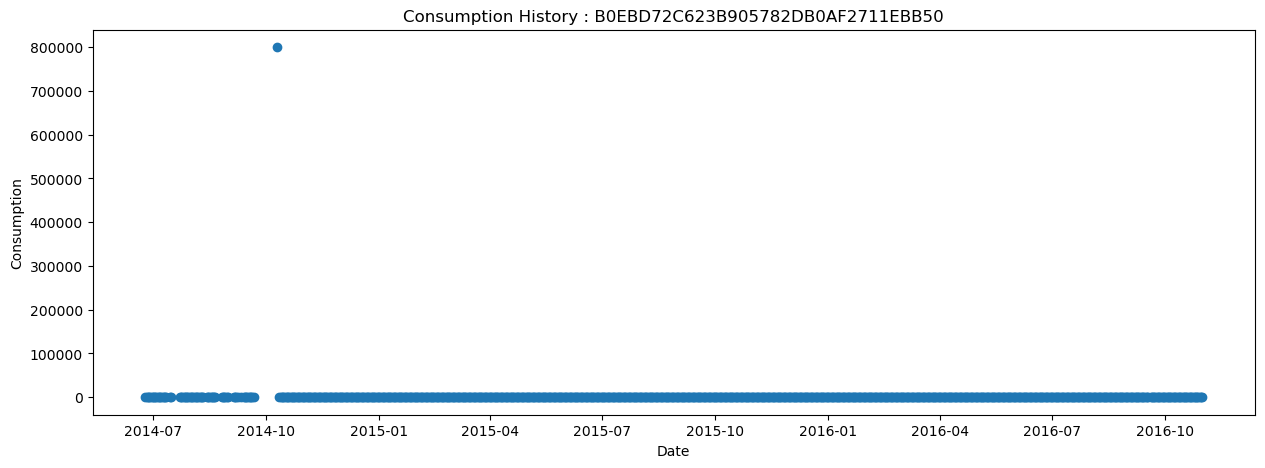

In [52]:
plt.figure(figsize=(15,5))
plt.scatter(history.index,history["consumption"])
plt.title(f"Consumption History : {consumer}")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()